# 2.5.6 Exercises

1. İkinci türev neden birinciden çok daha pahalı?İlk türev hesaplarken computation graph üzerinde bir backward pass yeterli. İkinci türev için ya:

Backward pass'ın kendisini bir kez daha differentiate etmen gerekir (backward-of-backward), bu graph'ı karesi kadar büyütür
Ya da Hessian matrisini tam hesaplaman gerekir: n parametren varsa Hessian n×n boyutunda, yani O(n²) bellek ve O(n²) ile O(n³) arası işlem
Pratikte büyük modellerde Hessian hesaplanamaz. GPT-3 için 175B parametre → 175B × 175B Hessian = fiziksel olarak imkansız.

- 2 

In [24]:
import torch
import matplotlib.pyplot as plt

In [3]:
x = torch.tensor([3.0], requires_grad=True)

In [9]:
y = x ** 2

In [10]:
y.backward()
print(x.grad)

tensor([13.])


In [11]:
y.backward()

RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

In [8]:
y.backward(retain_graph=True)

RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

In [17]:
f = torch.tensor([3.0])
f.requires_grad_(True)
f.backward()


In [18]:
f.backward(torch.ones_like(f))

In [19]:
torch.autograd.functional.jacobian(func, a)

NameError: name 'func' is not defined

In [20]:
x =torch.linspace(-2*torch.pi, 2*torch.pi, 100, requires_grad=True)

In [21]:
y = torch.sin(x)
y.sum().backward()
print(x.grad)

tensor([ 1.0000,  0.9920,  0.9679,  0.9284,  0.8738,  0.8053,  0.7237,  0.6306,
         0.5272,  0.4154,  0.2969,  0.1736,  0.0476, -0.0792, -0.2048, -0.3271,
        -0.4441, -0.5539, -0.6549, -0.7453, -0.8237, -0.8888, -0.9397, -0.9754,
        -0.9955, -0.9995, -0.9874, -0.9595, -0.9161, -0.8580, -0.7861, -0.7015,
        -0.6056, -0.5000, -0.3863, -0.2665, -0.1423, -0.0159,  0.1108,  0.2358,
         0.3569,  0.4723,  0.5801,  0.6785,  0.7660,  0.8413,  0.9029,  0.9501,
         0.9819,  0.9980,  0.9980,  0.9819,  0.9501,  0.9029,  0.8413,  0.7660,
         0.6785,  0.5801,  0.4723,  0.3569,  0.2358,  0.1108, -0.0159, -0.1423,
        -0.2665, -0.3863, -0.5000, -0.6056, -0.7015, -0.7861, -0.8580, -0.9161,
        -0.9595, -0.9874, -0.9995, -0.9955, -0.9754, -0.9397, -0.8888, -0.8237,
        -0.7453, -0.6549, -0.5539, -0.4441, -0.3271, -0.2048, -0.0792,  0.0476,
         0.1736,  0.2969,  0.4154,  0.5272,  0.6306,  0.7237,  0.8053,  0.8738,
         0.9284,  0.9679,  0.9920,  1.00

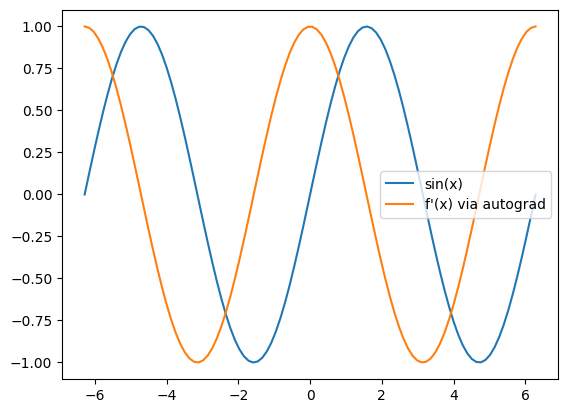

In [25]:
plt.plot(x.detach(), torch.sin(x.detach()), label='sin(x)')
plt.plot(x.detach(), x.grad, label="f'(x) via autograd")
plt.legend()
plt.show()